In [1]:
import stea
import pandas as pd
import scanpy as sc

# Deconvolution tutorial

In [2]:
markers = pd.read_csv("MOB_Rep12_markers.csv", index_col=0, header=0)    
adata = sc.read_h5ad("MOB_Rep12.h5ad")
adata.X.toarray()

array([[5., 1., 1., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [2., 1., 2., ..., 1., 1., 1.]], shape=(282, 16034), dtype=float32)

Folder 'stea_analysis' already exists.
STEA Analysis Pipeline Started

1. Quality Control Analysis...
Folder '01.QC' already exists.
Data has not been normalized! 

1. Marker Gene Ranking Analysis...
Folder '02.MarkerRank' already exists.
Found 5 cell types from genesets: ['PGC', 'GC', 'OSNs', 'M_TC', 'EPL-IN']
Saved original counts to adata.layers['counts']
Data shape: (16034, 282) (genes x cells)
Calculated expression ranks for each cell

Analyzing marker genes for PGC...
Using 50 available marker genes

Analyzing marker genes for GC...
Using 50 available marker genes

Analyzing marker genes for OSNs...
Using 50 available marker genes

Analyzing marker genes for M_TC...
Using 50 available marker genes

Analyzing marker genes for EPL-IN...
Using 50 available marker genes

2. Gene Set Enrichment Analysis...
Folder '03.ES' already exists.

STEA Analysis Pipeline Completed Successfully!


,celltype
16.918x16.996,GC
18.017x17.034,PGC
20.075x17.059,OSNs
18.979x17.065,OSNs
21.937x16.967,EPL-IN
...,...
18.97x26.953,OSNs
27.93x26.89,PGC
24.114x28.955,PGC
25.134x28.934,PGC


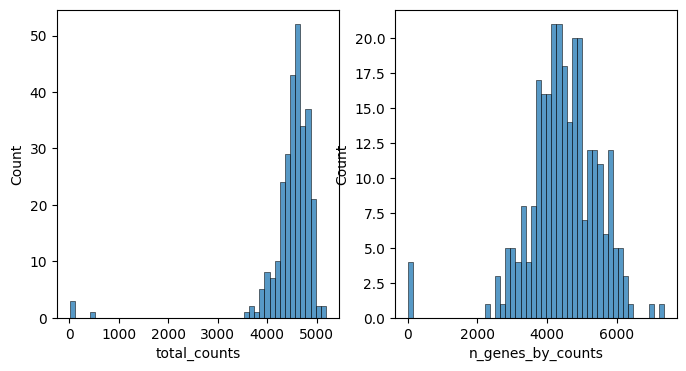

In [3]:
results = stea.stea(adata, markers, QC=True, folder="stea_analysis")
results

# Cosine Similarity

In [4]:
cos = stea.cosine_similarity(adata, "Nrsn1", top_n=None, folder="04.CosineSimilarity")
cos

Folder '04.CosineSimilarity' already exists.
Cosine similarity analysis completed for Nrsn1
Results saved to 04.CosineSimilarity/


,gene,cosine_similarity
3861,X2900097C17Rik,0.963171
4626,Sparcl1,0.963047
2784,Glul,0.959664
4568,Cpe,0.958374
2254,Gpm6b,0.957423
...,...,...
12992,Krt5,0.000000
12995,X1810024B03Rik,0.000000
14564,Mef2b,0.000000
11398,Dkk1,0.000000


/var/folders/83/fx8vxkgs4jggjl7n3jpsrvvc0000gn/T/ipykernel_18656/2570240204.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["Nrsn1", "X2900097C17Rik"])


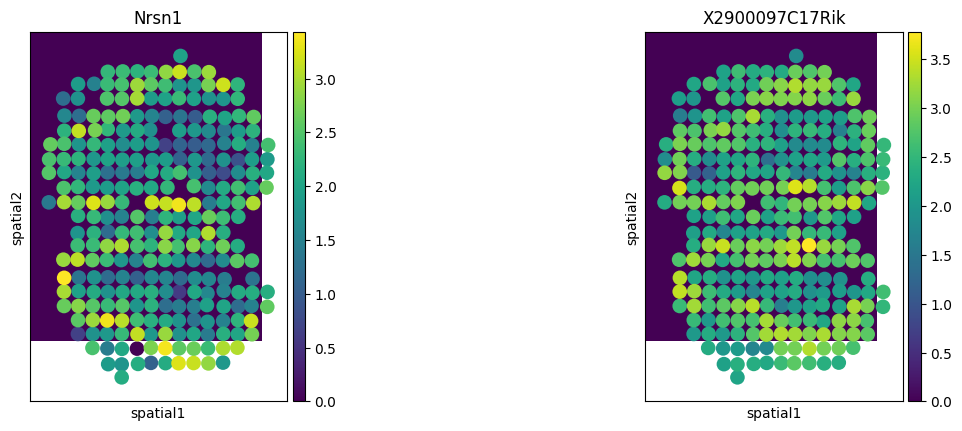

In [5]:
sc.pl.spatial(adata, color=["Nrsn1", "X2900097C17Rik"])

# JS divergence

In [6]:
res = stea.js_divergence(
    adata, markers,
    num_permutations=1000,
    permutation_method="random",
    random_state=0,
)

In [7]:
res

,celltype,marker,gene,js_divergence,p_value,fdr
0,PGC,Sparcl1,Gpm6b,0.003045,0.000999,0.001530
1,PGC,Sparcl1,X2900097C17Rik,0.008661,0.000999,0.001530
2,PGC,Sparcl1,Olfm1,0.011117,0.000999,0.001530
3,PGC,Sparcl1,Slc6a1,0.013080,0.000999,0.001530
4,PGC,Sparcl1,Slc6a11,0.016101,0.000999,0.001530
...,...,...,...,...,...,...
240,EPL-IN,Map1b,Rab26,0.468388,0.003996,0.004351
241,EPL-IN,Map1b,Tnfaip8,0.469115,0.005994,0.006385
242,EPL-IN,Map1b,A230065H16Rik,0.421276,0.018981,0.019789
243,EPL-IN,Map1b,Npr1,0.538949,0.105894,0.108100


In [8]:
res = stea.js_divergence(
    adata, markers,
    num_permutations=1000,
    permutation_method="spatial_blocks",
    block_n_bins=10,
    random_state=0,
)

In [9]:
res

,celltype,marker,gene,js_divergence,p_value,fdr
0,PGC,Sparcl1,Gpm6b,0.003045,0.000999,0.003263
1,PGC,Sparcl1,X2900097C17Rik,0.008661,0.000999,0.003263
2,PGC,Sparcl1,Olfm1,0.011117,0.000999,0.003263
3,PGC,Sparcl1,Slc6a1,0.013080,0.000999,0.003263
4,PGC,Sparcl1,Slc6a11,0.016101,0.000999,0.003263
...,...,...,...,...,...,...
240,EPL-IN,Map1b,Selm,0.060078,0.056943,0.062005
241,EPL-IN,Map1b,Ntng1,0.220314,0.074925,0.079811
242,EPL-IN,Map1b,Rab26,0.468388,0.196803,0.205178
243,EPL-IN,Map1b,Npr1,0.538949,0.228771,0.233537


In [ ]:
sc.pl.spatial(adata, )

In [ ]:
# 导入函数
from calculate_kl_simple import calculate_kl_simple

# 计算 Sparcl1 与所有其他基因的 KL divergence（带统计检验）
result = calculate_kl_simple(
    adata, 
    "Sparcl1",
    num_permutations=1000,  # 置换次数
    fdr_method='fdr_bh'      # FDR 校正方法，设为 None 可跳过
)

# 查看结果
print("Top 20 最相似的基因（KL 值最小）:")
print(result.head(20))

print("\n统计显著的结果 (FDR < 0.05):")
print(result[result['fdr'] < 0.05])

print("\n统计不显著的结果 (FDR >= 0.05):")
print(result[result['fdr'] >= 0.05])

result.to_csv("temp.csv")

In [29]:
result.head(7000)

,gene,kl_divergence,p_value,fdr
0,Glul,0.052700,0.000999,0.004450
1,Gpm6b,0.068287,0.000999,0.004450
2,Cst3,0.072126,0.000999,0.004450
3,Cpe,0.072146,0.000999,0.004450
4,Qk,0.080212,0.000999,0.004450
...,...,...,...,...
6995,Bcl9l,1.672763,0.021978,0.050139
6996,Laptm5,1.702709,0.021978,0.050139
6997,Tnks1bp1,1.706276,0.021978,0.050139
6998,Zdhhc18,1.714822,0.021978,0.050139


/var/folders/83/fx8vxkgs4jggjl7n3jpsrvvc0000gn/T/ipykernel_6291/3695433249.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["Sparcl1","Bcl9l"])


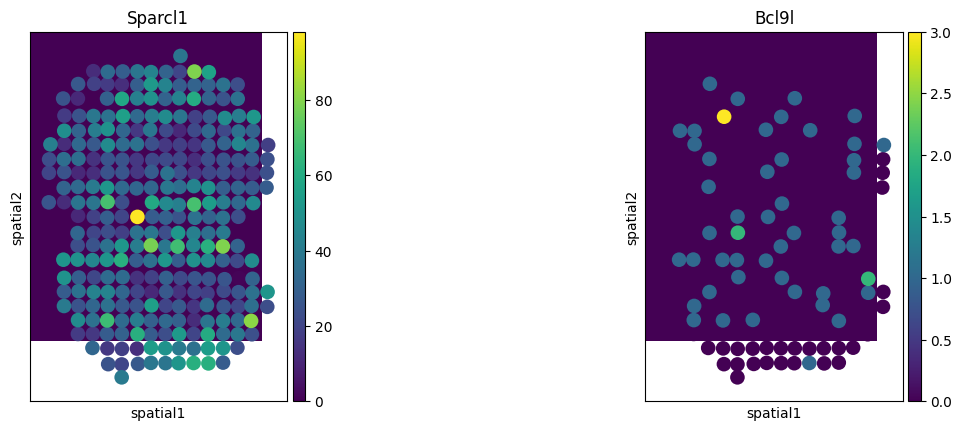

In [30]:
sc.pl.spatial(adata, color=["Sparcl1","Bcl9l"])